In [ ]:
# 1. Instal library Kaggle
!pip install kaggle

# 2. Buat direktori untuk menyimpan file API key
!mkdir -p ~/.kaggle

# 3. Impor library untuk mengunggah file
from google.colab import files

# 4. Minta pengguna mengunggah file kaggle.json
print("Silakan unggah file kaggle.json Anda:")
uploaded = files.upload()

# 5. Pindahkan file dan atur izinnya
for fn in uploaded.keys():
  !mv {fn} ~/.kaggle/kaggle.json
  !chmod 600 ~/.kaggle/kaggle.json

print("\nKonfigurasi Kaggle selesai!")

Silakan unggah file kaggle.json Anda:


Saving kaggle.json to kaggle.json

Konfigurasi Kaggle selesai!


In [ ]:
# 1. Unduh dataset kompetisi (ini mungkin memakan waktu beberapa menit)
!kaggle competitions download -c paddy-disease-classification

# 2. Buat direktori tujuan untuk dataset
!mkdir -p paddy-dataset

# 3. Ekstrak file zip ke direktori yang telah dibuat
# Opsi -q (quiet) digunakan agar tidak menampilkan daftar semua file
!unzip -q paddy-disease-classification.zip -d ./paddy-dataset

paddy-disease-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
replace ./paddy-dataset/sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
A



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from keras.layers import Input, Lambda, Dense, Flatten, Dropout
from keras.models import Model
from keras.applications import MobileNetV3Large
from keras.preprocessing import image
from keras.applications.mobilenet_v3 import preprocess_input
from keras.models import Sequential
from keras import layers, regularizers
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow import keras

In [ ]:
# Pastikan Anda sudah import library ini
import tensorflow_probability as tfp

# Konfigurasi untuk augmentasi
CUTMIX_ALPHA = 1.0
MIXUP_ALPHA = 0.8

# --- FUNGSI GET_BOX (TETAP SAMA, TIDAK BERUBAH DARI SEBELUMNYA) ---
def get_box(lam, image_height, image_width):
    """Mendapatkan koordinat bounding box untuk CutMix."""
    cut_ratio = tf.math.sqrt(1.0 - lam)

    box_height = tf.cast(cut_ratio * tf.cast(image_height, dtype=tf.float32), dtype=tf.int32)
    box_width = tf.cast(cut_ratio * tf.cast(image_width, dtype=tf.float32), dtype=tf.int32)

    random_x = tf.random.uniform(shape=[], minval=0, maxval=image_width, dtype=tf.int32)
    random_y = tf.random.uniform(shape=[], minval=0, maxval=image_height, dtype=tf.int32)

    x1 = tf.clip_by_value(random_x - box_width // 2, 0, image_width)
    y1 = tf.clip_by_value(random_y - box_height // 2, 0, image_height)
    x2 = tf.clip_by_value(random_x + box_width // 2, 0, image_width)
    y2 = tf.clip_by_value(random_y + box_height // 2, 0, image_height)

    return x1, y1, x2, y2

# --- FUNGSI HYBRID YANG SUDAH FINAL DAN STABIL ---
def hybrid_augment(images, labels):
    """
    Fungsi hybrid yang menerapkan CutMix atau Mixup pada satu batch data.
    """
    batch_size = tf.shape(images)[0]
    image_height = tf.shape(images)[1]
    image_width = tf.shape(images)[2]
    num_channels = tf.shape(images)[3] # Ambil jumlah channel

    tfd = tfp.distributions
    choice = tf.random.uniform([], 0, 1)

    indices = tf.range(start=0, limit=batch_size, dtype=tf.int32)
    shuffled_indices = tf.random.shuffle(indices)

    images_paired = tf.gather(images, shuffled_indices)
    labels_paired = tf.gather(labels, shuffled_indices)

    def apply_mixup():
        lam = tfd.Beta(MIXUP_ALPHA, MIXUP_ALPHA).sample(batch_size)
        lam_image = tf.reshape(lam, (batch_size, 1, 1, 1))
        lam_label = tf.reshape(lam, (batch_size, 1))

        mixed_images = (1.0 - lam_image) * tf.cast(images, tf.float32) + lam_image * tf.cast(images_paired, tf.float32)
        mixed_labels = (1.0 - lam_label) * tf.cast(labels, tf.float32) + lam_label * tf.cast(labels_paired, tf.float32)
        return mixed_images, mixed_labels

    def apply_cutmix():
        lam = tfd.Beta(CUTMIX_ALPHA, CUTMIX_ALPHA).sample()
        x1, y1, x2, y2 = get_box(lam, image_height, image_width)

        # Hitung lambda yang disesuaikan
        adjusted_lam = tf.cast((x2 - x1) * (y2 - y1), tf.float32) / (tf.cast(image_height * image_width, tf.float32))

        # --- CARA MEMBUAT MASK YANG PALING STABIL ---
        # 1. Buat patch berisi angka 1
        patch_ones = tf.ones([y2 - y1, x2 - x1, num_channels], dtype=tf.float32)

        # 2. Tambahkan padding nol di sekeliling patch
        paddings = [
            [y1, image_height - y2],
            [x1, image_width - x2],
            [0, 0] # Tidak ada padding untuk channel
        ]
        mask = tf.pad(patch_ones, paddings, "CONSTANT", constant_values=0)

        # 3. Broadcast mask ini ke seluruh batch
        mask = tf.broadcast_to(mask, tf.shape(images))
        # ----------------------------------------------

        mixed_images = (1.0 - mask) * tf.cast(images, tf.float32) + mask * tf.cast(images_paired, tf.float32)
        mixed_labels = (1.0 - adjusted_lam) * tf.cast(labels, tf.float32) + adjusted_lam * tf.cast(labels_paired, tf.float32)
        return mixed_images, mixed_labels

    return tf.cond(choice < 0.5, apply_mixup, apply_cutmix)

In [ ]:
# --- Konfigurasi Utama ---
DATA_DIR = './paddy-dataset/train_images'
IMG_SIZE = (256, 256)
BATCH_SIZE = 64

# --- Pemuatan & Pipeline Data ---
# Ubah batch_size menjadi None agar batching dilakukan manual nanti
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    label_mode='categorical',
    batch_size=None  # <-- PERUBAHAN KRUSIAL DI SINI
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    label_mode='categorical',
    batch_size=None  # <-- DAN DI SINI
)

class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)
print("Kelas Penyakit:", class_names)

# Hitung Class Weights (tetap sama)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Karena batch_size=None, kita perlu batch manual untuk menghitung bobot
y_train_int = np.concatenate([np.argmax(y, axis=1) for x, y in train_dataset.batch(BATCH_SIZE)], axis=0)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_int), y=y_train_int)
class_weight_dict = dict(enumerate(class_weights))
print("\nClass Weights:", class_weight_dict)

# --- Optimasi Pipeline ---
AUTOTUNE = tf.data.AUTOTUNE

# Cache dan shuffle seperti biasa
train_dataset = train_dataset.cache().shuffle(1000)

# Batching data TERLEBIH DAHULU
train_dataset = train_dataset.batch(BATCH_SIZE)

# Terapkan CutMix SETELAH batching
train_dataset = train_dataset.map(hybrid_augment, num_parallel_calls=AUTOTUNE).prefetch(buffer_size=AUTOTUNE)

# Validation set TIDAK menggunakan CutMix
validation_dataset = validation_dataset.batch(BATCH_SIZE).cache().prefetch(buffer_size=AUTOTUNE)

print("\n✅ Pipeline data dioptimalkan dengan CutMix untuk data training.")

Found 10407 files belonging to 10 classes.
Using 8326 files for training.
Found 10407 files belonging to 10 classes.
Using 2081 files for validation.
Kelas Penyakit: ['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']

Class Weights: {0: np.float64(2.1795811518324606), 1: np.float64(2.7032467532467535), 2: np.float64(2.9735714285714288), 3: np.float64(0.6055272727272727), 4: np.float64(1.0757105943152454), 5: np.float64(0.733568281938326), 6: np.float64(1.638976377952756), 7: np.float64(0.6514866979655712), 8: np.float64(0.5951393852751966), 9: np.float64(0.9386696730552424)}

✅ Pipeline data dioptimalkan dengan CutMix untuk data training.


In [ ]:
# --- Lapisan Augmentasi Data (Versi Ditingkatkan) ---
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),

    # Intensitas rotasi sedikit ditingkatkan
    keras.layers.RandomRotation(0.2),

    # Intensitas zoom & translasi sedikit ditingkatkan
    keras.layers.RandomZoom(0.2),
    keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2),

    # Intensitas kontras & kecerahan sedikit ditingkatkan
    keras.layers.RandomContrast(0.2),
    keras.layers.RandomBrightness(factor=0.2),

], name="data_augmentation")

In [ ]:
import tensorflow as tf
from keras import layers, regularizers, models
from keras.applications.mobilenet_v3 import preprocess_input # Import preprocess_input

# --- Definisikan Input & Augmentasi ---
inputs = layers.Input(shape=(256, 256, 3))
x = data_augmentation(inputs)

# --- Base Model (Frozen) ---
base_model = keras.applications.MobileNetV3Large(
    input_shape=(256, 256, 3),
    include_top=False,
    weights='imagenet',
    include_preprocessing=True # Gunakan preprocessor internal
)
base_model.trainable = False

# --- ARSITEKTUR CLASSIFIER HEAD "JALAN TENGAH" ---
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x) # <-- KEMBALIKAN SATU LAPISAN DENSE
x = layers.Dropout(0.3)(x)                   # <-- JAGA DROPOUT TETAP RENDAH
outputs = layers.Dense(len(class_names), activation='softmax')(x)
# ----------------------------------------------------

model = models.Model(inputs, outputs)
print("✅ Arsitektur FASE 1 dengan Classifier Head 'Jalan Tengah' berhasil dibuat.")

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:519: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ Arsitektur FASE 1 dengan Classifier Head 'Jalan Tengah' berhasil dibuat.


In [ ]:
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.optimizers.schedules import CosineDecay

# Tentukan path checkpoint
checkpoint_path = "/content/drive/MyDrive/PaddyPadi/checkpoints/mobilenetv3large_cutmix_cosine.keras"

# Atur callbacks yang optimal untuk CutMix
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        mode='max',
        patience=20, # Kesabaran yang ideal
        verbose=1,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=checkpoint_path,
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1
    )
]

# Definisikan jadwal CosineDecay untuk Fase 1
# Latih untuk 80 epoch, mulai dari LR 3e-4
cosine_schedule_phase1 = CosineDecay(
    initial_learning_rate=3e-4,
    decay_steps=80 * (8326 // BATCH_SIZE)
)

print("✅ Callbacks optimal dan CosineDecay LR Scheduler siap digunakan.")

✅ Callbacks optimal dan CosineDecay LR Scheduler siap digunakan.


In [ ]:
# --- Kompilasi Model dengan CosineDecay ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_schedule_phase1),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 8, 8, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 960)            │         3,840 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,248,778 (12.39 MB)

 Trainable params: 250,506 (978.54 KB)

 Non-trainable params: 2,998,272 (11.44 MB)

In [ ]:
# Gunakan callbacks adaptif Anda
print("\\n🚀 Memulai Pelatihan FASE 1 (Feature Extraction) dengan LR yang Dioptimalkan...")
history_phase1 = model.fit(
    train_dataset,
    epochs=70,
    validation_data=validation_dataset,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

\n🚀 Memulai Pelatihan FASE 1 (Feature Extraction) dengan LR yang Dioptimalkan...
Epoch 1/70
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.1477 - loss: 2.7088
Epoch 1: val_accuracy improved from None to 0.40125, saving model to /content/drive/MyDrive/PaddyPadi/checkpoints/mobilenetv3large_cutmix_cosine.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PaddyPadi/checkpoints/mobilenetv3large_cutmix_cosine.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 68s 387ms/step - accuracy: 0.1941 - loss: 2.5183 - val_accuracy: 0.4012 - val_loss: 1.7386
Epoch 2/70
130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.2825 - loss: 2.2408
Epoch 2: val_accuracy improved from 0.40125 to 0.47429, saving model to /content/drive/MyDrive/PaddyPadi/checkpoints/mobilenetv3large_cutmix_cosine.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PaddyPadi/checkpoints/mobilenetv3large_cutmix_cosine.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 26s 196ms/step - accuracy: 0.2989 - loss: 2.1974 - val_

In [ ]:
from keras.models import load_model

# Ganti dengan path checkpoint terbaik Anda dari pelatihan terakhir
best_checkpoint_path = "/content/drive/MyDrive/PaddyPadi/checkpoints/mobilenetv3large_cutmix_cosine.keras"

print(f"Memuat model dari checkpoint: {best_checkpoint_path}")

# Muat model dengan argumen custom_objects
model = load_model(best_checkpoint_path)

print("✅ Model terbaik berhasil dimuat.")
model.summary()

Memuat model dari checkpoint: /content/drive/MyDrive/PaddyPadi/checkpoints/mobilenetv3large_cutmix_cosine.keras
✅ Model terbaik berhasil dimuat.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 8, 8, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 960)            │         3,840 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,749,791 (14.30 MB)

 Trainable params: 250,506 (978.54 KB)

 Non-trainable params: 2,998,272 (11.44 MB)

 Optimizer params: 501,013 (1.91 MB)

In [ ]:
# Cairkan 80 lapisan teratas
base_model = model.get_layer('MobileNetV3Large') # Pastikan nama layer benar
base_model.trainable = True
fine_tune_at = -20
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
print(f"✅ {abs(fine_tune_at)} lapisan teratas (kecuali BN) kini dapat dilatih.")

✅ 20 lapisan teratas (kecuali BN) kini dapat dilatih.


In [ ]:
# Jalankan sel ini untuk mendefinisikan callbacks untuk fine-tuning

from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Siapkan callbacks untuk fine-tuning
finetune_v3_path = "/content/drive/MyDrive/PaddyPadi/checkpoints/mobilenetv3large_finetune.keras"
callbacks_finetune = [
    EarlyStopping(monitor='val_accuracy', mode='max', patience=15, verbose=1, restore_best_weights=True),
    ModelCheckpoint(filepath=finetune_v3_path, save_best_only=True, monitor='val_accuracy', mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', mode='max', factor=0.5, patience=5, verbose=1, min_lr=1e-7)
]

print("✅ Callbacks untuk fine-tuning (dengan ReduceLROnPlateau) siap digunakan.")

✅ Callbacks untuk fine-tuning (dengan ReduceLROnPlateau) siap digunakan.


In [ ]:
# Kompilasi dengan LR rendah untuk fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5), # Mulai dengan LR 5e-5
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

print("\n✅ Model V3Large siap untuk fine-tuning.")
model.summary()


✅ Model V3Large siap untuk fine-tuning.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 8, 8, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 960)            │         3,840 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,248,778 (12.39 MB)

 Trainable params: 1,197,306 (4.57 MB)

 Non-trainable params: 2,051,472 (7.83 MB)

In [ ]:
print("\n🚀 Memulai Pelatihan FASE 2 (Fine-Tuning MobileNetV3Large)...")

history_phase2 = model.fit(
    train_dataset,
    epochs=140, # Target epoch
    initial_epoch=70, # Melanjutkan dari akhir sesi sebelumnya
    validation_data=validation_dataset,
    callbacks=callbacks_finetune,
    class_weight=class_weight_dict
)

print("\n🏁 Pelatihan fine-tuning MobileNetV3Large selesai!")


🚀 Memulai Pelatihan FASE 2 (Fine-Tuning MobileNetV3Large)...
Epoch 71/140
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.5936 - loss: 1.4948
Epoch 71: val_accuracy improved from None to 0.66939, saving model to /content/drive/MyDrive/PaddyPadi/checkpoints/mobilenetv3large_finetune.keras

Epoch 71: finished saving model to /content/drive/MyDrive/PaddyPadi/checkpoints/mobilenetv3large_finetune.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 68s 376ms/step - accuracy: 0.5891 - loss: 1.5017 - val_accuracy: 0.6694 - val_loss: 0.9819 - learning_rate: 5.0000e-05
Epoch 72/140
130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.6143 - loss: 1.4518
Epoch 72: val_accuracy improved from 0.66939 to 0.67708, saving model to /content/drive/MyDrive/PaddyPadi/checkpoints/mobilenetv3large_finetune.keras

Epoch 72: finished saving model to /content/drive/MyDrive/PaddyPadi/checkpoints/mobilenetv3large_finetune.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 25s 191ms/step - accuracy: 0.6079 - loss: 1.4717 - val_acc

Model final V2-B3 berhasil disimpan di: /content/drive/MyDrive/PaddyPadi/final_model_v3large_82acc.keras

 Mengevaluasi performa model V3Large pada data validasi...

Laporan Klasifikasi V3Large:

                          precision    recall  f1-score   support

   bacterial_leaf_blight       0.82      0.82      0.82        97
   bacterial_leaf_streak       0.74      0.96      0.84        72
bacterial_panicle_blight       0.77      0.95      0.85        57
                   blast       0.82      0.85      0.84       363
              brown_spot       0.89      0.68      0.77       191
              dead_heart       0.97      0.91      0.94       307
            downy_mildew       0.50      0.93      0.65       112
                   hispa       0.85      0.74      0.79       316
                  normal       0.91      0.85      0.88       365
                  tungro       0.83      0.77      0.80       201

                accuracy                           0.83      2081
          

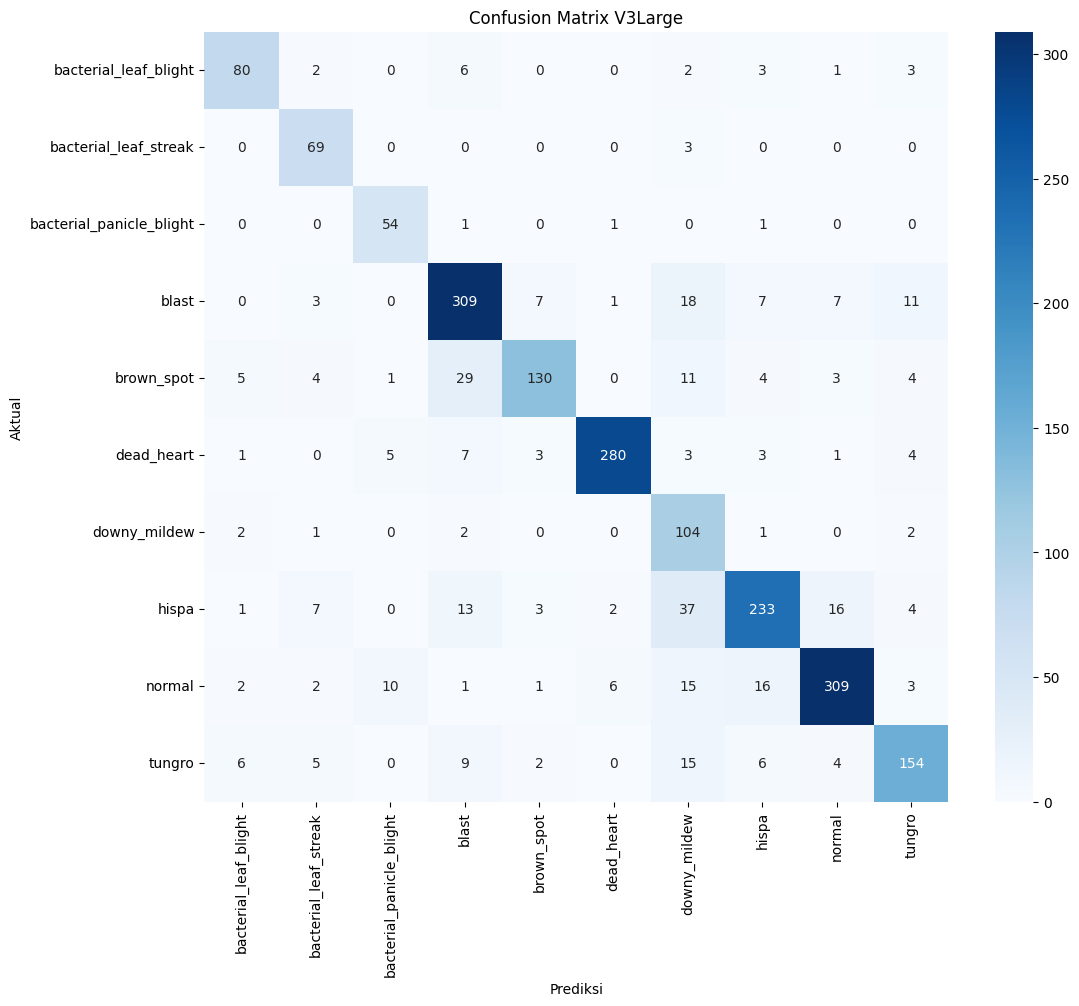

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# EarlyStopping sudah memuat bobot terbaik dari Epoch 99 ke dalam 'model'

# 1. Simpan model final Anda dengan nama yang jelas
final_model_path_v3large = "/content/drive/MyDrive/PaddyPadi/final_model_v3large_82acc.keras"
model.save(final_model_path_v3large)
print(f"Model final V2-B3 berhasil disimpan di: {final_model_path_v3large}")

# 2. Lakukan evaluasi komprehensif
print("\n Mengevaluasi performa model V3Large pada data validasi...")
y_true = []
y_pred_probs = []
for images, labels in validation_dataset:
    y_true.extend(np.argmax(labels.numpy(), axis=-1))
    y_pred_probs.extend(model.predict(images, verbose=0))
y_pred = np.argmax(y_pred_probs, axis=-1)

# 3. Cetak Laporan Klasifikasi
print("\nLaporan Klasifikasi V3Large:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. Tampilkan Confusion Matrix
print("\nConfusion Matrix V3Large:\n")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix V3Large')
plt.show()

In [ ]:
from keras.models import load_model
import tensorflow as tf

# Muat model terbaik dari Fase 3
best_model_path = "/content/drive/MyDrive/PaddyPadi/checkpoints/mobilenetv3large_finetune.keras"
print(f"Memuat model terbaik dari: {best_model_path}")
model = load_model(best_model_path)

Memuat model terbaik dari: /content/drive/MyDrive/PaddyPadi/checkpoints/mobilenetv3large_finetune.keras


In [ ]:
# Dapatkan lapisan base model
base_model = model.get_layer('MobileNetV3Large')
for layer in base_model.layers:
    layer.trainable = True

# Jaga agar lapisan BatchNormalization tetap beku
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("✅ Seluruh lapisan base model (kecuali BN) kini dapat dilatih.")

✅ Seluruh lapisan base model (kecuali BN) kini dapat dilatih.


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5), # <-- LR sangat kecil untuk polesan akhir
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)
print("✅ Model berhasil dikompilasi ulang.")
model.summary()

✅ Model berhasil dikompilasi ulang.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 8, 8, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 960)            │         3,840 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,248,778 (12.39 MB)

 Trainable params: 3,198,058 (12.20 MB)

 Non-trainable params: 50,720 (198.12 KB)

In [ ]:
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Tentukan path checkpoint BARU untuk fase ini
full_finetune_path = "/content/drive/MyDrive/PaddyPadi/checkpoints/mobilenetv3large_finetune_full.keras"

callbacks_full_finetune = [
    EarlyStopping(
        monitor='val_accuracy',
        mode='max',
        patience=10,  # <-- Kurangi kesabaran agar lebih cepat berhenti jika performa menurun
        verbose=1,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=full_finetune_path,
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        mode='max',
        factor=0.5,  # <-- Penurunan LR lebih halus (setengahnya)
        patience=4,  # <-- Lebih reaktif terhadap plateau
        verbose=1,
        min_lr=1e-8
    )
]

print("✅ Callbacks untuk fine-tuning penuh (lebih sensitif) siap digunakan.")

✅ Callbacks untuk fine-tuning penuh (lebih sensitif) siap digunakan.


In [ ]:
# --- Melanjutkan Pelatihan (FASE 3) ---

print("\\n🚀 Memulai Pelatihan FASE 3 (Fine-Tuning Dalam)...")

history_phase3 = model.fit(
    train_dataset,
    epochs=200, # Beri target baru
    initial_epoch=140, # Melanjutkan dari epoch terakhir
    validation_data=validation_dataset,
    callbacks=callbacks_full_finetune, # Gunakan callbacks yang sama
    class_weight=class_weight_dict
)

print("\\n🏁 Pelatihan FASE 3 Selesai!")

\n🚀 Memulai Pelatihan FASE 3 (Fine-Tuning Dalam)...
Epoch 141/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.7088 - loss: 1.2877
Epoch 141: val_accuracy improved from None to 0.83998, saving model to /content/drive/MyDrive/PaddyPadi/checkpoints/mobilenetv3large_finetune_full.keras

Epoch 141: finished saving model to /content/drive/MyDrive/PaddyPadi/checkpoints/mobilenetv3large_finetune_full.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 68s 365ms/step - accuracy: 0.7037 - loss: 1.2813 - val_accuracy: 0.8400 - val_loss: 0.5535 - learning_rate: 3.0000e-05
Epoch 142/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.7378 - loss: 1.2474
Epoch 142: val_accuracy improved from 0.83998 to 0.84431, saving model to /content/drive/MyDrive/PaddyPadi/checkpoints/mobilenetv3large_finetune_full.keras

Epoch 142: finished saving model to /content/drive/MyDrive/PaddyPadi/checkpoints/mobilenetv3large_finetune_full.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 48s 368ms/step - accuracy: 0.7380 - loss: 

In [ ]:
from keras.models import load_model

# Ganti dengan path checkpoint terbaik Anda dari pelatihan terakhir
best_full_model = "/content/drive/MyDrive/PaddyPadi/checkpoints/mobilenetv3large_finetune_full.keras"

print(f"Memuat model dari checkpoint: {best_full_model}")

# Muat model dengan argumen custom_objects
model = load_model(best_full_model)

print("✅ Model terbaik berhasil dimuat.")
model.summary()

Memuat model dari checkpoint: /content/drive/MyDrive/PaddyPadi/checkpoints/mobilenetv3large_finetune_full.keras
✅ Model terbaik berhasil dimuat.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 8, 8, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 960)            │         3,840 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,644,896 (36.79 MB)

 Trainable params: 3,198,058 (12.20 MB)

 Non-trainable params: 50,720 (198.12 KB)

 Optimizer params: 6,396,118 (24.40 MB)

In [ ]:
# EarlyStopping sudah memulihkan bobot terbaik
final_model_path_full_finetune = "/content/drive/MyDrive/PaddyPadi/mobilenetv3large_93acc.keras"
model.save(final_model_path_full_finetune)
print(f"Model final terbaik (~93% val acc) berhasil disimpan di: {final_model_path_full_finetune}")

Model final terbaik (~93% val acc) berhasil disimpan di: /content/drive/MyDrive/PaddyPadi/mobilenetv3large_93acc.keras



 Mengevaluasi performa model final V3Large...

Laporan Klasifikasi Final V3Large:

                          precision    recall  f1-score   support

   bacterial_leaf_blight     0.9691    0.9691    0.9691        97
   bacterial_leaf_streak     0.8987    0.9861    0.9404        72
bacterial_panicle_blight     0.8750    0.9825    0.9256        57
                   blast     0.9513    0.9146    0.9326       363
              brown_spot     0.9543    0.8743    0.9126       191
              dead_heart     0.9711    0.9837    0.9773       307
            downy_mildew     0.7883    0.9643    0.8675       112
                   hispa     0.9600    0.9114    0.9351       316
                  normal     0.9363    0.9260    0.9311       365
                  tungro     0.9087    0.9403    0.9242       201

                accuracy                         0.9346      2081
               macro avg     0.9213    0.9452    0.9315      2081
            weighted avg     0.9372    0.9346    0.9349 

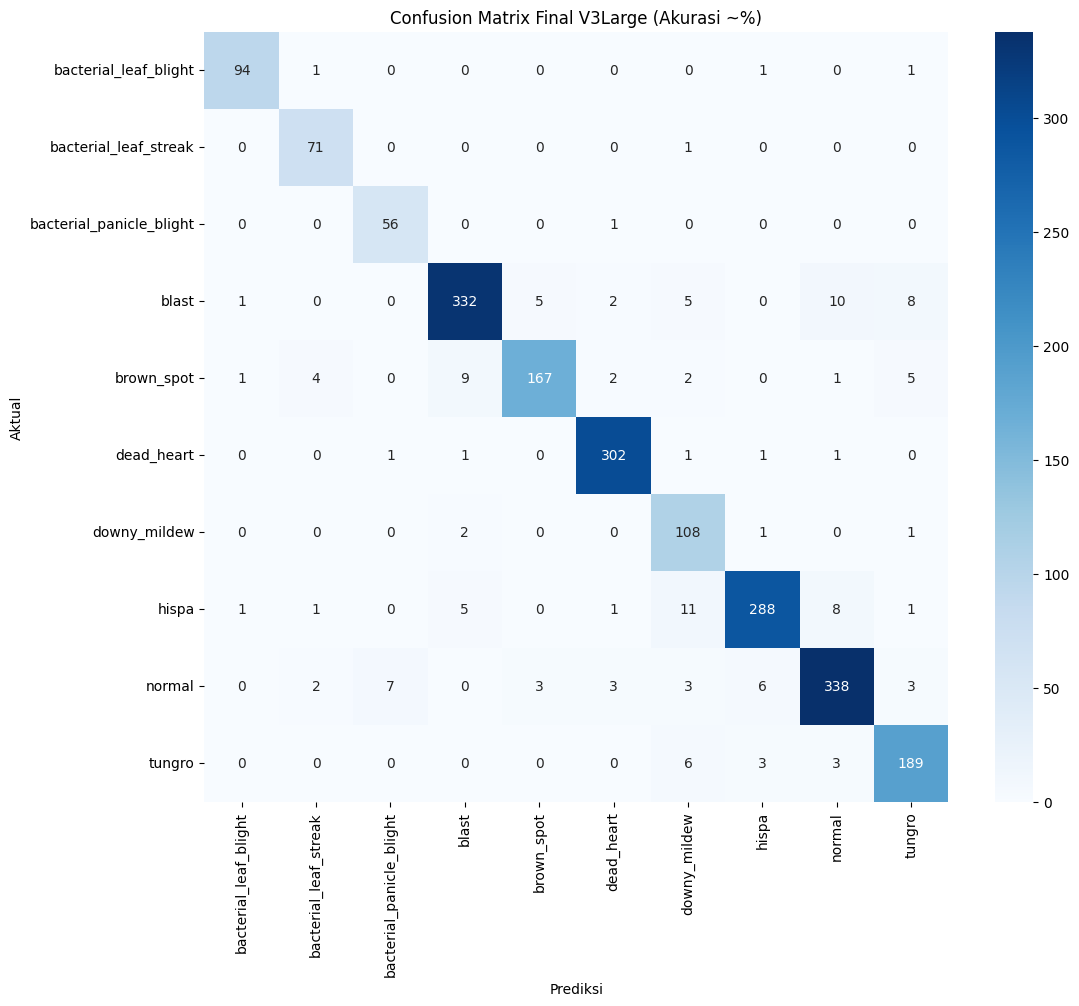

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Lakukan evaluasi komprehensif untuk melihat detail performa
print("\n Mengevaluasi performa model final V3Large...")
y_true = []
y_pred_probs = []
for images, labels in validation_dataset:
    y_true.extend(np.argmax(labels.numpy(), axis=-1))
    y_pred_probs.extend(model.predict(images, verbose=0))
y_pred = np.argmax(y_pred_probs, axis=-1)

# 3. Cetak Laporan Klasifikasi
print("\nLaporan Klasifikasi Final V3Large:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# 4. Tampilkan Confusion Matrix
print("\nConfusion Matrix Final V3Large:\n")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Final V3Large (Akurasi ~%)')
plt.show()

In [ ]:
from keras.models import load_model
import tensorflow as tf

# Muat model terbaik dari Fase 3
best_model_path = "/content/drive/MyDrive/PaddyPadi/mobilenetv3large_93acc.keras"
print(f"Memuat model terbaik dari: {best_model_path}")
model = load_model(best_model_path)

Memuat model terbaik dari: /content/drive/MyDrive/PaddyPadi/mobilenetv3large_93acc.keras


In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import accuracy_score

# Fungsi predict_with_tta (tetap sama seperti sebelumnya)
def predict_with_tta(image_path, model):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array_expanded = tf.expand_dims(img_array, 0)
    img_flipped = tf.image.flip_left_right(img_array_expanded)
    images_batch = tf.concat([img_array_expanded, img_flipped], axis=0)
    predictions = model.predict(images_batch, verbose=0)
    mean_prediction = tf.reduce_mean(predictions, axis=0)
    return mean_prediction.numpy()

print("Mempersiapkan file dan label untuk evaluasi TTA...")

# --- PERBAIKAN: Dapatkan file path & label dari sumbernya langsung ---
# Buat ulang dataset validasi TAPI tanpa .cache() atau .prefetch() dan JANGAN DI-SHUFFLE.
# Ini untuk memastikan urutan file path dan label 100% cocok.
val_ds_for_eval = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    label_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False # SANGAT PENTING!
)

# Ambil daftar file path dari sini
validation_files = val_ds_for_eval.file_paths

# Ambil label asli dari sini (sebagai indeks angka, misal: 0, 1, 2, ...)
y_true_indices = np.concatenate([np.argmax(y, axis=-1) for x, y in val_ds_for_eval], axis=0)
# --- AKHIR PERBAIKAN ---


print("\nMemulai prediksi TTA untuk setiap gambar (mungkin butuh beberapa saat)...")
# Loop TTA untuk membuat prediksi
y_pred_indices_tta = []
for file_path in tqdm(validation_files):
    pred_probs = predict_with_tta(file_path, model)
    predicted_class_index = np.argmax(pred_probs)
    y_pred_indices_tta.append(predicted_class_index)

# Hitung akurasi TTA
tta_accuracy = accuracy_score(y_true_indices, y_pred_indices_tta)

# Sebagai perbandingan, lakukan juga prediksi normal (non-TTA)
print("\nMemulai prediksi normal untuk perbandingan...")
y_pred_probs_normal = model.predict(val_ds_for_eval)
y_pred_indices_normal = np.argmax(y_pred_probs_normal, axis=-1)
original_accuracy = accuracy_score(y_true_indices, y_pred_indices_normal)


# Tampilkan hasil perbandingan
print("\n--- HASIL EVALUASI ---")
print(f"Akurasi Asli (dihitung ulang): {original_accuracy:.4f}")
print(f"Akurasi dengan TTA: {tta_accuracy:.4f}")
print(f"Peningkatan: {tta_accuracy - original_accuracy:.4f}")

Mempersiapkan file dan label untuk evaluasi TTA...
Found 10407 files belonging to 10 classes.
Using 2081 files for validation.

Memulai prediksi TTA untuk setiap gambar (mungkin butuh beberapa saat)...


100%|██████████| 2081/2081 [03:54<00:00,  8.88it/s]



Memulai prediksi normal untuk perbandingan...
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 260ms/step

--- HASIL EVALUASI ---
Akurasi Asli (dihitung ulang): 0.9457
Akurasi dengan TTA: 0.9294
Peningkatan: -0.0163


In [ ]:
from keras.models import load_model

# Pastikan path ini sesuai dengan model final terbaik Anda
final_model_path = "/content/drive/MyDrive/PaddyPadi/mobilenetv3large_93acc.keras"

print(f"Memuat model terbaik dari: {final_model_path}")
model = load_model(final_model_path)

# Siapkan juga class_names untuk interpretasi hasil
class_names = [
    'bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight',
    'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro'
]
IMG_SIZE = (224, 224) # Pastikan IMG_SIZE sesuai dengan saat pelatihan

Memuat model terbaik dari: /content/drive/MyDrive/PaddyPadi/mobilenetv3large_93acc.keras


Silakan unggah gambar dari komputer Anda:


Saving 100063.jpg to 100063.jpg

Gambar '100063.jpg' berhasil diunggah.


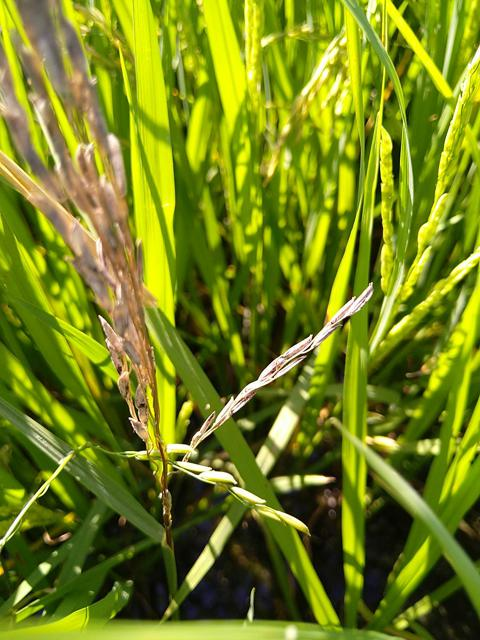

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

🧠 HASIL PREDIKSI UTAMA:
🎯 Kelas: dead_heart
✅ Keyakinan: 22.70%


📊 RINCIAN KEYAKINAN PER KELAS (dari tertinggi ke terendah):
- dead_heart: 22.70%
- normal: 8.65%
- hispa: 8.62%
- blast: 8.60%
- bacterial_leaf_streak: 8.58%
- tungro: 8.57%
- bacterial_panicle_blight: 8.57%
- brown_spot: 8.57%
- bacterial_leaf_blight: 8.57%
- downy_mildew: 8.57%


In [ ]:
import numpy as np
from google.colab import files
import tensorflow as tf
from IPython.display import Image, display

# ----------------------------------------------------
# BAGIAN 0: PASTIKAN MODEL DAN CLASS_NAMES SUDAH ADA
# ----------------------------------------------------
# Pastikan model Anda sudah dimuat ke dalam variabel 'model'
# Pastikan daftar 'class_names' sudah tersedia dari pipeline data Anda

try:
    model
    class_names
except NameError:
    print("='*'*20")
    print("HARAP MUAT ULANG MODEL DAN 'class_names' TERLEBIH DAHULU!")
    print("Jalankan sel kode untuk memuat model dan sel pipeline data Anda.")
    print("='*'*20")


# ----------------------------------------------------
# BAGIAN 1: UPLOAD GAMBAR INTERAKTIF
# ----------------------------------------------------
print("Silakan unggah gambar dari komputer Anda:")
uploaded = files.upload()
filename = next(iter(uploaded))
print(f"\nGambar '{filename}' berhasil diunggah.")
display(Image(filename, width=250))


# ----------------------------------------------------
# BAGIAN 2: PERSIAPAN GAMBAR UNTUK MODEL
# ----------------------------------------------------
IMG_SIZE = (256, 256)
img = tf.keras.utils.load_img(filename, target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(img)
image_batch = tf.expand_dims(img_array, 0)


# ----------------------------------------------------
# BAGIAN 3: LAKUKAN PREDIKSI
# ----------------------------------------------------
predictions = model.predict(image_batch)
score = tf.nn.softmax(predictions[0])


# ----------------------------------------------------
# BAGIAN 4: TAMPILKAN HASIL PREDIKSI (YANG DIPERBARUI)
# ----------------------------------------------------
# Prediksi teratas
predicted_class_index = np.argmax(score)
confidence = 100 * np.max(score)
predicted_class_name = class_names[predicted_class_index]

print(f"\n🧠 HASIL PREDIKSI UTAMA:")
print(f"🎯 Kelas: {predicted_class_name}")
print(f"✅ Keyakinan: {confidence:.2f}%")

# --- TAMBAHAN: Rincian Keyakinan untuk Setiap Kelas ---
print("\n\n📊 RINCIAN KEYAKINAN PER KELAS (dari tertinggi ke terendah):")

# Buat daftar pasangan (kelas, skor) dan urutkan
scores_per_class = sorted(zip(class_names, score.numpy()), key=lambda x: x[1], reverse=True)

# Tampilkan setiap kelas beserta skor keyakinannya
for class_name, class_score in scores_per_class:
    print(f"- {class_name}: {100 * class_score:.2f}%")

🔍 Layer ekstraksi fitur yang dianalisis: conv_1

🎯 HASIL PREDIKSI AKHIR : BACTERIAL_PANICLE_BLIGHT
✅ TINGKAT KEYAKINAN    : 57.77%



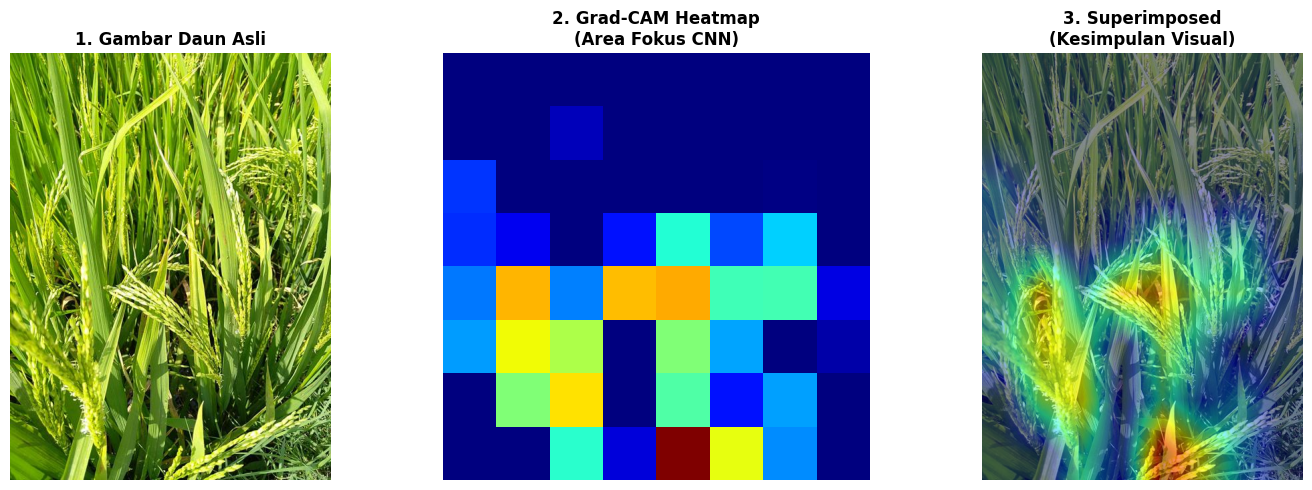

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing import image

def make_gradcam_heatmap_nested(img_array, model, pred_index=None):
    """
    Fungsi khusus Grad-CAM untuk membedah arsitektur Nested:
    Input -> Data Augmentation -> MobileNetV3Large (Base) -> GAP -> BN -> Dense -> Output
    """
    # 1. Ambil Base Model (MobileNetV3Large) dari model utama Anda
    base_model = model.get_layer('MobileNetV3Large')

    # 2. Cari layer konvolusi 2D terakhir di dalam MobileNetV3Large secara otomatis
    last_conv_layer_name = None
    for layer in reversed(base_model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer_name = layer.name
            break

    print(f"🔍 Layer ekstraksi fitur yang dianalisis: {last_conv_layer_name}")

    # 3. Buat model gradien internal (untuk menarik peta fitur dari base model)
    inner_grad_model = tf.keras.models.Model(
        [base_model.inputs],
        [base_model.get_layer(last_conv_layer_name).output, base_model.output]
    )

    # 4. Lakukan forward pass secara manual di bawah pengawasan GradientTape
    with tf.GradientTape() as tape:
        # Melewati layer Data Augmentation (index 1) dengan training=False
        # agar gambar uji tidak terputar/teracak oleh augmentasi
        x = model.layers[1](img_array, training=False)

        # Melewati inner_grad_model untuk menarik peta fitur & output base model
        conv_outputs, base_outputs = inner_grad_model(x)

        # Melanjutkan perjalanan ke sisa layer di model utama (GAP, BN, Dense, Dropout)
        # Dimulai dari layer index ke-3 (0=Input, 1=Augmentasi, 2=MobileNetV3Large)
        x = base_outputs
        for layer in model.layers[3:]:
            x = layer(x, training=False)

        preds = x # Output akhir probabilitas (Softmax)

        # Jika index kelas tidak dispesifikasikan, ambil kelas dengan probabilitas tertinggi
        if pred_index is None:
            pred_index = tf.argmax(preds[0])

        # Ambil nilai probabilitas murni dari kelas yang diprediksi
        class_channel = preds[:, pred_index]

    # 5. Hitung gradien kelas target terhadap peta fitur konvolusi
    grads = tape.gradient(class_channel, conv_outputs)

    # 6. Rata-ratakan gradien secara spasial (Global Average Pooling pada gradien)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 7. Kalikan channel peta fitur dengan "bobot kepentingan" (gradien) dari channel tersebut
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 8. Normalisasi heatmap (dengan ReLU dan membaginya dengan nilai maksimum) ke rentang 0-1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy(), preds.numpy(), pred_index.numpy()

def display_gradcam_overlay(img_path, heatmap, alpha=0.4):
    """
    Fungsi untuk menumpuk (superimpose) heatmap Grad-CAM ke atas gambar daun asli
    """
    # Baca gambar asli dengan OpenCV
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Pastikan format warna adalah RGB

    # Ubah resolusi heatmap agar ukurannya sama persis dengan resolusi gambar daun
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Konversi nilai heatmap menjadi pewarnaan RGB (Colormap JET: Biru=Dingin, Merah=Panas)
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_colormap = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_colormap = cv2.cvtColor(heatmap_colormap, cv2.COLOR_BGR2RGB)

    # Tumpuk/Gabungkan gambar asli dengan warna heatmap
    superimposed_img = cv2.addWeighted(heatmap_colormap, alpha, img, 1 - alpha, 0)

    # Visualisasi Berjejer menggunakan Matplotlib
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("1. Gambar Daun Asli", fontsize=12, fontweight='bold')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap='jet')
    plt.title("2. Grad-CAM Heatmap\n(Area Fokus CNN)", fontsize=12, fontweight='bold')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(superimposed_img)
    plt.title("3. Superimposed\n(Kesimpulan Visual)", fontsize=12, fontweight='bold')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# =====================================================================
# BLOK EKSEKUSI PENGUJIAN
# =====================================================================

# Daftar kelas dataset yang sedang Anda gunakan (berdasarkan urutan abjad direktori keras)
class_names = ['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight',
               'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']

# Gunakan gambar yang baru saja Anda tes/unggah
image_path_to_test = '100314.jpg'

# Preprocessing Gambar
# Menyesuaikan dengan input arsitektur awal yaitu 256x256
img = image.load_img(image_path_to_test, target_size=(256, 256))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Tambahkan dimensi batch menjadi (1, 256, 256, 3)

# *Catatan: Tidak perlu memanggil preprocess_input() dari Keras karena MobileNetV3Large
# Anda dibuat dengan argumen include_preprocessing=True. Model sudah memprosesnya secara mandiri.

# Eksekusi Pembuatan Heatmap
heatmap, predictions, predicted_class_idx = make_gradcam_heatmap_nested(img_array, model)

# Ekstraksi Hasil
predicted_class_name = class_names[predicted_class_idx]
confidence = np.max(predictions) * 100

print("\n" + "="*50)
print(f"🎯 HASIL PREDIKSI AKHIR : {predicted_class_name.upper()}")
print(f"✅ TINGKAT KEYAKINAN    : {confidence:.2f}%")
print("="*50 + "\n")

# Tampilkan Hasil Visualisasi XAI (Explainable AI)
display_gradcam_overlay(image_path_to_test, heatmap, alpha=0.45)